# Финальный проект: анализ продаж супермаркета

Данные о заказах (orders.xlsx) и товарах (products.xlsx) за 13.01.2022.

orders - чеки: order_id, accepted_at, product_id, quantity, regular_price, price, cost_price
products - справочник товаров: product_id, level1 (категория), level2 (подкатегория), name

В заданиях, кроме расчета среднего чека, товары из orders, которых нет в products, не учитываем (inner join).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'


In [2]:
orders = pd.read_excel('orders.xlsx')
products = pd.read_excel('products.xlsx')

print('orders:', orders.shape)
print('products:', products.shape)
orders.head()


orders: (3323, 7)
products: (40152, 4)


,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [3]:
products.head()


,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


Сколько товаров из orders не находится в products (их не берем в расчет дальше):

In [4]:
missing_products = orders.loc[~orders['product_id'].isin(products['product_id']), 'product_id'].nunique()
missing_rows = (~orders['product_id'].isin(products['product_id'])).sum()
print(f'Товаров без карточки: {missing_products}, строк в orders: {missing_rows} из {len(orders)}')


Товаров без карточки: 157, строк в orders: 305 из 3323


In [5]:
# соединяем чеки со справочником товаров, товары без карточки в products отваливаются
df = orders.merge(products, on='product_id', how='inner')
df['revenue'] = df['price'] * df['quantity']
df['cost'] = df['cost_price'] * df['quantity']
df['margin'] = df['revenue'] - df['cost']
df['is_promo'] = df['price'] < df['regular_price']

df.head()


,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,revenue,cost,margin,is_promo
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,169,74,95,False
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,169,74,95,False
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,169,74,95,False
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат,219,130,89,False
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат,219,130,89,False


## 1. Самая ходовая товарная группа

Суммарное количество проданных штук по каждой категории level1.

In [6]:
qty_by_level1 = (
    df.groupby('level1')['quantity']
    .sum()
    .sort_values(ascending=False)
    .rename('quantity')
    .to_frame()
)
qty_by_level1['share_%'] = (qty_by_level1['quantity'] / qty_by_level1['quantity'].sum() * 100).round(1)

top_category = qty_by_level1.index[0]
print(f'Самая ходовая товарная группа: "{top_category}", {int(qty_by_level1.iloc[0]["quantity"])} шт.')
qty_by_level1


Самая ходовая товарная группа: "Безалкогольные напитки", 534 шт.


,quantity,share_%
level1,,
Безалкогольные напитки,534,14.3
Молочная продукция,483,12.9
Свежие овощи,262,7.0
Кулинария,250,6.7
Бакалея,239,6.4
Хлеб и хлебобулочные изделия,218,5.8
Снэки,212,5.7
Свежие фрукты,184,4.9
Замороженная продукция,175,4.7


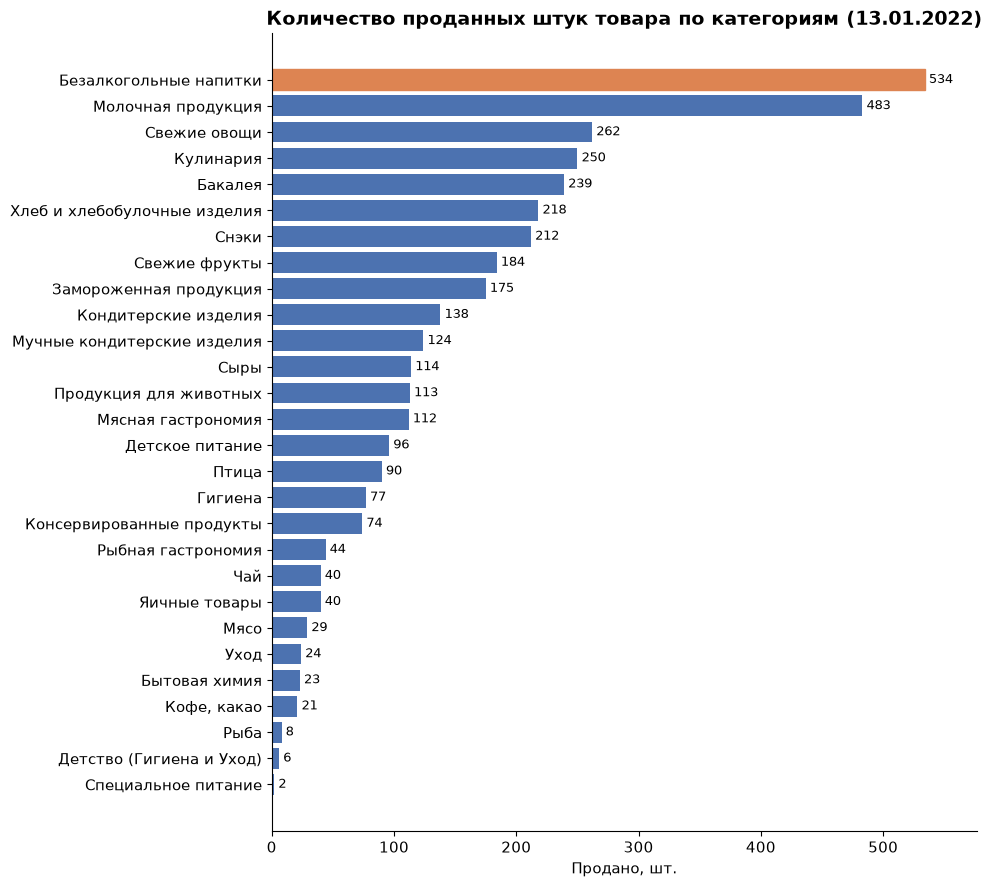

In [7]:
fig, ax = plt.subplots(figsize=(10, 9))
data = qty_by_level1.sort_values('quantity')
bars = ax.barh(data.index, data['quantity'], color='#4C72B0')
bars[-1].set_color('#DD8452')  # лидер

ax.set_title('Количество проданных штук товара по категориям (13.01.2022)')
ax.set_xlabel('Продано, шт.')
ax.set_ylabel('')
ax.bar_label(bars, padding=3, fontsize=9)
ax.margins(x=0.08)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_1_top_category.png', dpi=150)
plt.show()


## 2. Распределение продаж по подкатегориям

Для каждой категории level1 смотрим, как продажи распределены по подкатегориям level2, и какая доля приходится на каждую из них внутри своей категории.

In [8]:
qty_by_level2 = (
    df.groupby(['level1', 'level2'])['quantity']
    .sum()
    .reset_index()
    .sort_values(['level1', 'quantity'], ascending=[True, False])
)

qty_by_level2['share_in_level1_%'] = (
    qty_by_level2['quantity'] / qty_by_level2.groupby('level1')['quantity'].transform('sum') * 100
).round(1)

qty_by_level2 = qty_by_level2.reset_index(drop=True)
print(f'Всего подкатегорий: {qty_by_level2["level2"].nunique()} в {qty_by_level2["level1"].nunique()} категориях')
qty_by_level2


Всего подкатегорий: 100 в 28 категориях


,level1,level2,quantity,share_in_level1_%
0,Бакалея,Сухие блюда быстрого приготовления,38,15.9
1,Бакалея,"Крупы, бобовые",30,12.6
2,Бакалея,Зерновые для завтраков,24,10.0
3,Бакалея,Макаронные изделия,24,10.0
4,Бакалея,Соусы,24,10.0
...,...,...,...,...
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218,100.0
96,Чай,Черный чай,26,65.0
97,Чай,Зеленый чай,7,17.5
98,Чай,Чайные напитки,7,17.5


Для примера - разбивка топ-категории по подкатегориям.

In [9]:
qty_by_level2[qty_by_level2['level1'] == top_category]


,level1,level2,quantity,share_in_level1_%
11,Безалкогольные напитки,Напитки,252,47.2
12,Безалкогольные напитки,Воды питьевые,162,30.3
13,Безалкогольные напитки,Соковая продукция,82,15.4
14,Безалкогольные напитки,Воды минеральные,38,7.1


## 3. Средний чек 13.01.2022

Тут берем все заказы из orders целиком, без фильтра по products - для суммы чека категория товара не важна. В файле и так только 13.01.2022, но на всякий случай проверим диапазон дат.

In [10]:
print('Диапазон дат в orders:', orders['accepted_at'].min(), '-', orders['accepted_at'].max())


Диапазон дат в orders: 2022-01-13 08:00:30 - 2022-01-13 22:58:29


In [11]:
orders_all = orders.copy()
orders_all['revenue'] = orders_all['price'] * orders_all['quantity']
orders_all['date'] = orders_all['accepted_at'].dt.date

target_date = pd.Timestamp('2022-01-13').date()
day_orders = orders_all[orders_all['date'] == target_date]

check_by_order = day_orders.groupby('order_id')['revenue'].sum()
avg_check = check_by_order.mean()

print(f'Дата: {target_date}')
print(f'Количество чеков: {check_by_order.shape[0]}')
print(f'Суммарная выручка: {check_by_order.sum():.0f} руб.')
print(f'Средний чек: {avg_check:.2f} руб.')


Дата: 2022-01-13
Количество чеков: 544
Суммарная выручка: 498107 руб.
Средний чек: 915.64 руб.


## 4. Доля промо в категории «Сыры»

Промо - когда фактическая цена (price) ниже базовой (regular_price). Смотрим долю промо-продаж в штуках по категории level1 == 'Сыры'.

In [12]:
cheese = df[df['level1'] == 'Сыры']

promo_qty = cheese.loc[cheese['is_promo'], 'quantity'].sum()
regular_qty = cheese.loc[~cheese['is_promo'], 'quantity'].sum()
total_qty = promo_qty + regular_qty

print(f'Категория "Сыры": всего продано {total_qty} шт.')
print(f'Промо: {promo_qty} шт. ({promo_qty / total_qty:.1%})')
print(f'Обычная цена: {regular_qty} шт. ({regular_qty / total_qty:.1%})')


Категория "Сыры": всего продано 114 шт.
Промо: 35 шт. (30.7%)
Обычная цена: 79 шт. (69.3%)


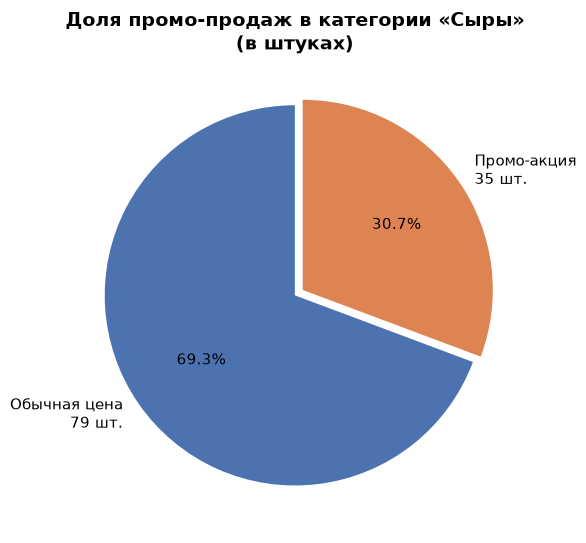

In [13]:
labels = [f'Обычная цена\n{regular_qty} шт.', f'Промо-акция\n{promo_qty} шт.']
values = [regular_qty, promo_qty]
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.05),
    textprops={'fontsize': 11},
)
ax.set_title('Доля промо-продаж в категории «Сыры»\n(в штуках)')
plt.tight_layout()
plt.savefig('chart_2_promo_share_cheese.png', dpi=150)
plt.show()


## 5. Маржа по категориям

Маржа = выручка (price * quantity) минус себестоимость (cost_price * quantity). Считаем в рублях и в процентах от выручки, по каждой категории level1.

In [14]:
margin_by_level1 = df.groupby('level1').agg(
    revenue=('revenue', 'sum'),
    cost=('cost', 'sum'),
    margin_rub=('margin', 'sum'),
).sort_values('margin_rub', ascending=False)

margin_by_level1['margin_pct'] = (margin_by_level1['margin_rub'] / margin_by_level1['revenue'] * 100).round(1)
margin_by_level1


,revenue,cost,margin_rub,margin_pct
level1,,,,
Безалкогольные напитки,46107,25734,20373,44.2
Кулинария,40840,22388,18452,45.2
Замороженная продукция,27714,14615,13099,47.3
Молочная продукция,37582,25089,12493,33.2
Мясная гастрономия,24150,13920,10230,42.4
Снэки,22477,12895,9582,42.6
Свежие овощи,33222,24216,9006,27.1
Бакалея,21766,13589,8177,37.6
Свежие фрукты,27009,19130,7879,29.2


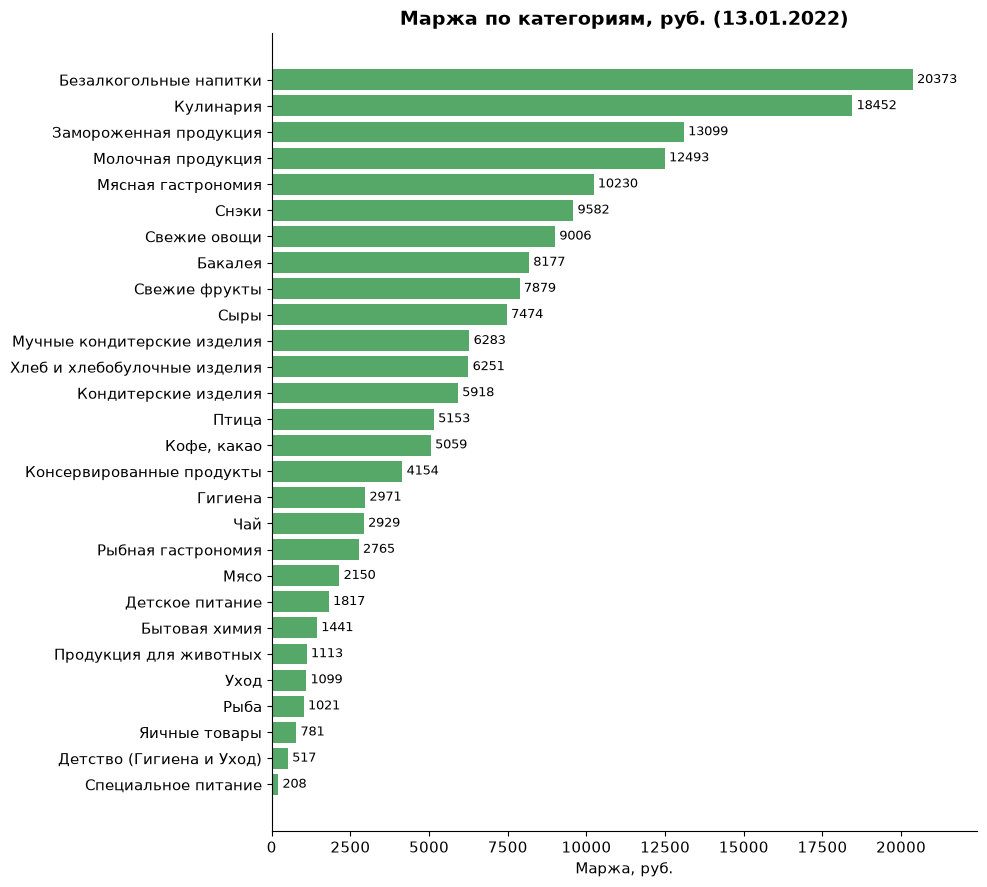

In [15]:
fig, ax = plt.subplots(figsize=(10, 9))
data = margin_by_level1.sort_values('margin_rub')
bars = ax.barh(data.index, data['margin_rub'], color='#55A868')

ax.set_title('Маржа по категориям, руб. (13.01.2022)')
ax.set_xlabel('Маржа, руб.')
ax.bar_label(bars, padding=3, fontsize=9)
ax.margins(x=0.1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_3_margin_rub.png', dpi=150)
plt.show()


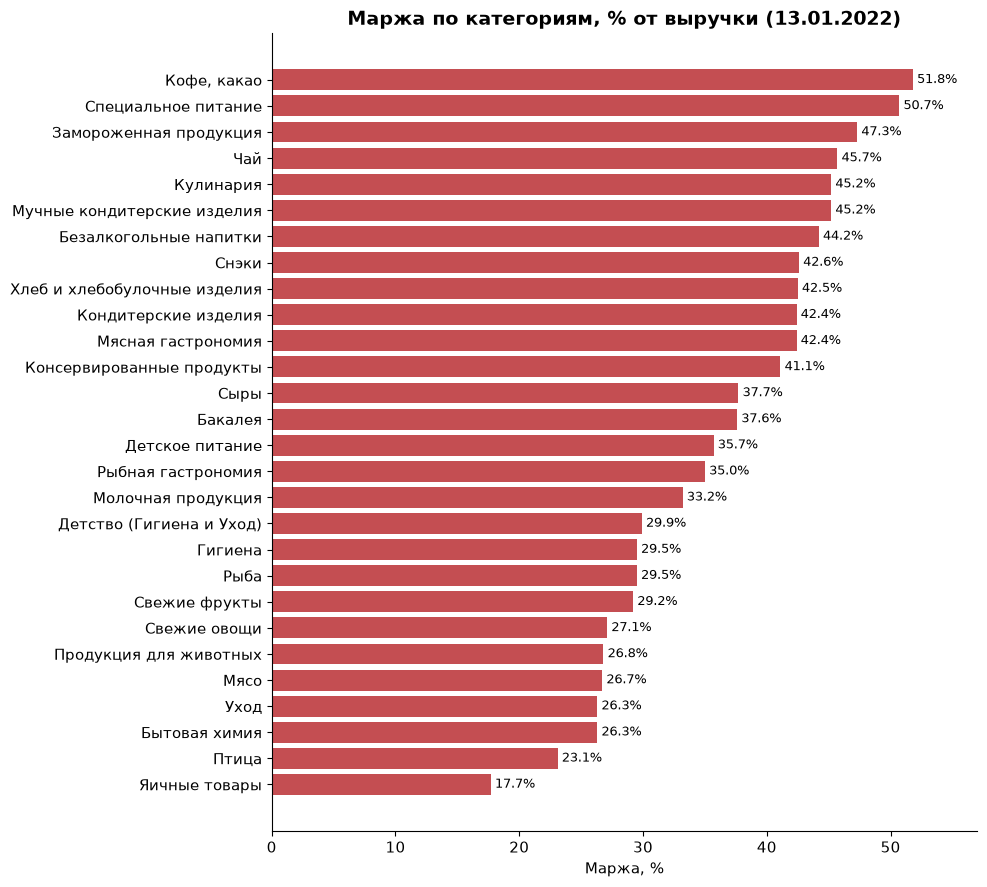

In [16]:
fig, ax = plt.subplots(figsize=(10, 9))
data = margin_by_level1.sort_values('margin_pct')
bars = ax.barh(data.index, data['margin_pct'], color='#C44E52')

ax.set_title('Маржа по категориям, % от выручки (13.01.2022)')
ax.set_xlabel('Маржа, %')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.margins(x=0.1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_4_margin_pct.png', dpi=150)
plt.show()


## 6. ABC-анализ

Делаем ABC-анализ на уровне подкатегорий level2 (по товарам данных за один день маловато, а подкатегорий и так 100 штук). Отдельно по количеству, отдельно по сумме продаж. Границы групп стандартные: A - первые 80% накопленного итога, B - до 95%, C - остальное.

In [17]:
def abc_classify(series):
    # ABC-группа для каждого элемента серии по накопленной доле
    ordered = series.sort_values(ascending=False)
    cum_share = ordered.cumsum() / ordered.sum()
    groups = pd.cut(cum_share, bins=[0, 0.8, 0.95, 1.0001], labels=['A', 'B', 'C'])
    return groups.reindex(series.index)


sub_totals = df.groupby('level2').agg(
    quantity=('quantity', 'sum'),
    revenue=('revenue', 'sum'),
)

sub_totals['ABC_quantity'] = abc_classify(sub_totals['quantity'])
sub_totals['ABC_revenue'] = abc_classify(sub_totals['revenue'])
sub_totals['ABC_group'] = sub_totals['ABC_quantity'].astype(str) + ' ' + sub_totals['ABC_revenue'].astype(str)

abc_result = sub_totals.sort_values('revenue', ascending=False)
abc_result


,quantity,revenue,ABC_quantity,ABC_revenue,ABC_group
level2,,,,,
Готовые блюда,248,40356,A,A,A A
Напитки,252,24123,A,A,A A
Мясо птицы охлажденное,90,22349,A,A,A A
"Тепличные овощи, грибы",105,18329,A,A,A A
Снэки соленые,180,17293,A,A,A A
...,...,...,...,...,...
Средства для сантехники,1,239,C,C,C C
"Какао, горячий шоколад",2,238,C,C,C C
Уход за одеждой и обувью,3,235,C,C,C C


Сколько подкатегорий попало в каждое сочетание групп:

In [18]:
abc_result['ABC_group'].value_counts().rename('subcategories').to_frame()


,subcategories
ABC_group,
C C,32
A A,23
B B,15
C B,10
B A,9
A B,5
B C,4
A C,2
